# Week 15 V6: Balanced Tasks for CodeGnosis Evaluation

## Problem with V5
All 10 tasks failed without retrieval (0% baseline), so we couldn't train a real classifier.

## Solution: Balanced Task Design
- **Easy tasks**: General httpx knowledge the model likely knows
- **Hard tasks**: Specific internal details requiring source code

Target: ~50% baseline accuracy so we have both classes to train on.

In [1]:
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers scikit-learn

In [2]:
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
from typing import List, Dict, Tuple
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Clone httpx
!git clone --depth 1 https://github.com/encode/httpx.git /content/httpx 2>/dev/null || true

def load_source_files(repo_dir: str) -> Dict[str, str]:
    files = {}
    for root, _, filenames in os.walk(os.path.join(repo_dir, 'httpx')):
        for fname in filenames:
            if fname.endswith('.py'):
                fpath = os.path.join(root, fname)
                rel_path = os.path.relpath(fpath, repo_dir)
                with open(fpath, 'r', encoding='utf-8') as f:
                    files[rel_path] = f.read()
    return files

SOURCE_FILES = load_source_files('/content/httpx')
print(f"Loaded {len(SOURCE_FILES)} source files")

Loaded 23 source files


In [4]:
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager", # Add this line to enable attention outputs
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Models loaded!")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded!


## Balanced Tasks: Easy + Hard

**Easy tasks** (model should know from training):
- Basic httpx usage patterns
- Common API methods
- General concepts

**Hard tasks** (requires source code):
- Exact parameter names
- Default values
- Internal class names

In [5]:
# BALANCED TASKS: Mix of easy and hard
TASKS = [
    # ===== EASY TASKS (model likely knows) =====
    {
        'id': 1,
        'difficulty': 'easy',
        'question': 'How do you make a simple GET request using httpx?',
        'relevant_file': 'httpx/_api.py',
        'verify': lambda r: 'httpx.get' in r.lower() or 'get(' in r.lower(),
        'ground_truth': 'httpx.get(url)',
    },
    {
        'id': 2,
        'difficulty': 'easy',
        'question': 'How do you make a POST request with JSON data using httpx?',
        'relevant_file': 'httpx/_api.py',
        'verify': lambda r: 'post' in r.lower() and 'json' in r.lower(),
        'ground_truth': 'httpx.post(url, json=data)',
    },
    {
        'id': 3,
        'difficulty': 'easy',
        'question': 'How do you access the response body as text in httpx?',
        'relevant_file': 'httpx/_models.py',
        'verify': lambda r: '.text' in r.lower() or 'response.text' in r.lower(),
        'ground_truth': 'response.text',
    },
    {
        'id': 4,
        'difficulty': 'easy',
        'question': 'How do you access the JSON response body in httpx?',
        'relevant_file': 'httpx/_models.py',
        'verify': lambda r: '.json()' in r.lower() or 'response.json' in r.lower(),
        'ground_truth': 'response.json()',
    },
    {
        'id': 5,
        'difficulty': 'easy',
        'question': 'How do you check the HTTP status code of a response in httpx?',
        'relevant_file': 'httpx/_models.py',
        'verify': lambda r: 'status_code' in r.lower(),
        'ground_truth': 'response.status_code',
    },
    {
        'id': 6,
        'difficulty': 'easy',
        'question': 'How do you create an httpx Client for making multiple requests?',
        'relevant_file': 'httpx/_client.py',
        'verify': lambda r: 'client' in r.lower() and ('with' in r.lower() or 'httpx.client' in r.lower()),
        'ground_truth': 'with httpx.Client() as client:',
    },
    {
        'id': 7,
        'difficulty': 'easy',
        'question': 'How do you set a timeout for requests in httpx?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: 'timeout' in r.lower(),
        'ground_truth': 'httpx.get(url, timeout=10.0)',
    },
    {
        'id': 8,
        'difficulty': 'easy',
        'question': 'How do you add custom headers to an httpx request?',
        'relevant_file': 'httpx/_api.py',
        'verify': lambda r: 'headers' in r.lower(),
        'ground_truth': 'httpx.get(url, headers={"X-Custom": "value"})',
    },
    {
        'id': 9,
        'difficulty': 'easy',
        'question': 'Does httpx support async requests? If so, how?',
        'relevant_file': 'httpx/_client.py',
        'verify': lambda r: 'async' in r.lower() and ('asyncclient' in r.lower() or 'await' in r.lower()),
        'ground_truth': 'async with httpx.AsyncClient() as client: await client.get(url)',
    },
    {
        'id': 10,
        'difficulty': 'easy',
        'question': 'How do you send form data in an httpx POST request?',
        'relevant_file': 'httpx/_api.py',
        'verify': lambda r: 'data' in r.lower() or 'form' in r.lower(),
        'ground_truth': 'httpx.post(url, data={"key": "value"})',
    },

    # ===== HARD TASKS (requires source code) =====
    {
        'id': 11,
        'difficulty': 'hard',
        'question': 'What is the exact default timeout value in seconds for httpx requests?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: '5.0' in r or ('5' in r and '30' not in r and '10' not in r),
        'ground_truth': '5.0 seconds',
    },
    {
        'id': 12,
        'difficulty': 'hard',
        'question': 'What is the exact value of DEFAULT_MAX_REDIRECTS in httpx?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: '20' in r,
        'ground_truth': '20',
    },
    {
        'id': 13,
        'difficulty': 'hard',
        'question': 'What are the exact 3 parameters of httpx.Limits.__init__()?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: 'max_connections' in r.lower() and 'keepalive_expiry' in r.lower() and 'max_retries' not in r.lower(),
        'ground_truth': 'max_connections, max_keepalive_connections, keepalive_expiry',
    },
    {
        'id': 14,
        'difficulty': 'hard',
        'question': 'What is the default value for max_connections in httpx.Limits? Is it 100, 50, or None?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: 'none' in r.lower(),
        'ground_truth': 'None',
    },
    {
        'id': 15,
        'difficulty': 'hard',
        'question': 'List ALL 5 authentication classes defined in httpx._auth module.',
        'relevant_file': 'httpx/_auth.py',
        'verify': lambda r: 'basicauth' in r.lower() and 'digestauth' in r.lower() and 'netrcauth' in r.lower(),
        'ground_truth': 'Auth, BasicAuth, DigestAuth, FunctionAuth, NetRCAuth',
    },
    {
        'id': 16,
        'difficulty': 'hard',
        'question': 'What is the parent class of ConnectError in httpx._exceptions? Is it Exception, HTTPError, or NetworkError?',
        'relevant_file': 'httpx/_exceptions.py',
        'verify': lambda r: 'networkerror' in r.lower(),
        'ground_truth': 'NetworkError',
    },
    {
        'id': 17,
        'difficulty': 'hard',
        'question': 'What exception does httpx raise for unsupported URL schemes like ftp://?',
        'relevant_file': 'httpx/_exceptions.py',
        'verify': lambda r: 'unsupportedprotocol' in r.lower(),
        'ground_truth': 'UnsupportedProtocol',
    },
    {
        'id': 18,
        'difficulty': 'hard',
        'question': 'What are the 2 base transport classes in httpx._transports.base?',
        'relevant_file': 'httpx/_transports/base.py',
        'verify': lambda r: 'basetransport' in r.lower() and 'asyncbasetransport' in r.lower(),
        'ground_truth': 'BaseTransport, AsyncBaseTransport',
    },
    {
        'id': 19,
        'difficulty': 'hard',
        'question': 'What is the default value of keepalive_expiry in httpx.Limits?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: '5.0' in r or '5 ' in r or 'five' in r.lower(),
        'ground_truth': '5.0 seconds',
    },
    {
        'id': 20,
        'difficulty': 'hard',
        'question': 'What are the 5 timeout components in httpx.Timeout (timeout, connect, read, write, and what else)?',
        'relevant_file': 'httpx/_config.py',
        'verify': lambda r: 'pool' in r.lower(),
        'ground_truth': 'timeout, connect, read, write, pool',
    },
]

easy_count = sum(1 for t in TASKS if t['difficulty'] == 'easy')
hard_count = sum(1 for t in TASKS if t['difficulty'] == 'hard')
print(f"Created {len(TASKS)} tasks: {easy_count} easy, {hard_count} hard")

Created 20 tasks: 10 easy, 10 hard


## Build Retrieval Index

In [6]:
def create_chunks(source_files: Dict[str, str], chunk_size: int = 80) -> List[Dict]:
    chunks = []
    for filepath, content in source_files.items():
        lines = content.split('\n')
        for i in range(0, len(lines), chunk_size // 2):
            chunk_lines = lines[i:i + chunk_size]
            if len(chunk_lines) < 10:
                continue
            chunks.append({
                'filepath': filepath,
                'start_line': i,
                'content': '\n'.join(chunk_lines),
            })
    return chunks

CHUNKS = create_chunks(SOURCE_FILES)
print(f"Created {len(CHUNKS)} chunks")

chunk_texts = [f"{c['filepath']}:\n{c['content']}" for c in CHUNKS]
CHUNK_EMBEDDINGS = embedder.encode(chunk_texts, show_progress_bar=True, convert_to_tensor=True)
print(f"Embeddings: {CHUNK_EMBEDDINGS.shape}")

Created 224 chunks


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings: torch.Size([224, 384])


In [7]:
def retrieve(query: str, top_k: int = 3, target_file: str = None) -> str:
    """Retrieve relevant source code chunks."""
    query_emb = embedder.encode(query, convert_to_tensor=True)
    sims = F.cosine_similarity(query_emb.unsqueeze(0), CHUNK_EMBEDDINGS)

    if target_file:
        for i, chunk in enumerate(CHUNKS):
            if target_file in chunk['filepath']:
                sims[i] += 0.3

    top_idx = torch.topk(sims, k=min(top_k, len(CHUNKS))).indices

    parts = []
    for idx in top_idx:
        chunk = CHUNKS[idx.item()]
        parts.append(f"# From {chunk['filepath']} (line {chunk['start_line']}):\n{chunk['content']}")

    return "\n\n".join(parts)

## CodeGnosis Feature Extraction

In [8]:
def generate_with_features(prompt: str, context: str = None, max_tokens: int = 250) -> Tuple[str, Dict]:
    """
    Generate answer and extract CodeGnosis features.
    Returns: (answer_text, features_dict)
    """
    if context:
        full_prompt = f"""[INST] Use this source code to answer the question:

{context}

Question: {prompt}

Answer based ONLY on the source code above. Be specific and precise. [/INST]"""
    else:
        full_prompt = f"""[INST] Answer this question about the httpx Python library:

{prompt}

Be specific and precise. [/INST]"""

    inputs = tokenizer(full_prompt, return_tensors='pt').to(model.device)
    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask

    # Collect features during generation
    all_hidden_states = []
    all_attentions = []
    all_entropies = []

    generated_ids = input_ids.clone()
    current_mask = attention_mask.clone()

    for _ in range(max_tokens):
        with torch.no_grad():
            outputs = model(
                input_ids=generated_ids,
                attention_mask=current_mask,
                output_hidden_states=True,
                output_attentions=True,
            )

        logits = outputs.logits[:, -1, :]

        # Compute entropy (CCE)
        probs = F.softmax(logits, dim=-1)
        entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=-1)
        all_entropies.append(entropy.item())

        # Get hidden states from last layer
        last_hidden = outputs.hidden_states[-1][:, -1, :]
        all_hidden_states.append(last_hidden.cpu().float().numpy())

        # Get attention entropy
        last_attention = outputs.attentions[-1]
        attn_probs = last_attention[:, :, -1, :]
        attn_entropy = -torch.sum(attn_probs * torch.log(attn_probs + 1e-10), dim=-1).mean()
        all_attentions.append(attn_entropy.item())

        # Sample next token
        next_token = torch.argmax(logits, dim=-1, keepdim=True)
        generated_ids = torch.cat([generated_ids, next_token], dim=-1)
        current_mask = torch.cat([current_mask, torch.ones((1, 1), device=model.device, dtype=current_mask.dtype)], dim=1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    response = tokenizer.decode(generated_ids[0][input_ids.shape[1]:], skip_special_tokens=True)

    # Compute aggregate features
    hs_array = np.vstack(all_hidden_states)
    features = {
        'hs_mean_norm': np.mean(np.linalg.norm(hs_array, axis=1)),
        'hs_std_norm': np.std(np.linalg.norm(hs_array, axis=1)),
        'hs_max_norm': np.max(np.linalg.norm(hs_array, axis=1)),
        'cce_mean': np.mean(all_entropies),
        'cce_max': np.max(all_entropies),
        'cce_std': np.std(all_entropies),
        'cce_spikes': sum(1 for e in all_entropies if e > np.mean(all_entropies) + 2*np.std(all_entropies)),
        'attn_mean': np.mean(all_attentions),
        'attn_max': np.max(all_attentions),
        'attn_std': np.std(all_attentions),
        'response_length': len(all_entropies),
    }

    return response.strip(), features

In [9]:
def generate_simple(prompt: str, context: str = None, max_tokens: int = 250) -> str:
    """Simple generation without feature extraction."""
    if context:
        full_prompt = f"""[INST] Use this source code to answer the question:

{context}

Question: {prompt}

Answer based ONLY on the source code above. Be specific and precise. [/INST]"""
    else:
        full_prompt = f"""[INST] Answer this question about the httpx Python library:

{prompt}

Be specific and precise. [/INST]"""

    inputs = tokenizer(full_prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return response.strip()

## Phase 1: Collect Training Data

In [10]:
%%time

print("Phase 1: Collecting training data with balanced tasks...")
print("="*70)

training_data = []

for task in TASKS:
    print(f"\n[Task {task['id']:2d}] [{task['difficulty'].upper():4s}] {task['question'][:45]}...")

    # Generate WITHOUT retrieval and collect features
    answer, features = generate_with_features(task['question'], context=None)

    # Check if correct
    is_correct = task['verify'](answer)

    training_data.append({
        'task_id': task['id'],
        'difficulty': task['difficulty'],
        'question': task['question'],
        'answer': answer,
        'is_correct': is_correct,
        'features': features,
        'ground_truth': task['ground_truth'],
        'relevant_file': task['relevant_file'],
    })

    status = "OK" if is_correct else "WRONG"
    print(f"  Status: {status}")
    print(f"  CCE: mean={features['cce_mean']:.3f}, max={features['cce_max']:.3f}, spikes={features['cce_spikes']}")
    print(f"  Answer: {answer[:80]}...")

Phase 1: Collecting training data with balanced tasks...

[Task  1] [EASY] How do you make a simple GET request using ht...
  Status: OK
  CCE: mean=0.289, max=1.844, spikes=14
  Answer: To make a simple GET request using the `httpx` library in Python, you can use th...

[Task  2] [EASY] How do you make a POST request with JSON data...
  Status: OK
  CCE: mean=0.334, max=2.234, spikes=14
  Answer: To make a POST request with JSON data using the `httpx` library in Python, you c...

[Task  3] [EASY] How do you access the response body as text i...
  Status: OK
  CCE: mean=0.235, max=2.062, spikes=14
  Answer: To access the response body as text in httpx, you can use the `text()` method of...

[Task  4] [EASY] How do you access the JSON response body in h...
  Status: OK
  CCE: mean=0.344, max=2.109, spikes=11
  Answer: To access the JSON response body in httpx, you can use the `response.json()` met...

[Task  5] [EASY] How do you check the HTTP status code of a re...
  Status: OK
  CCE: 

In [11]:
# Baseline summary
print("\n" + "="*70)
print("BASELINE SUMMARY (No Retrieval)")
print("="*70)

correct_count = sum(1 for d in training_data if d['is_correct'])
total = len(training_data)

easy_correct = sum(1 for d in training_data if d['difficulty'] == 'easy' and d['is_correct'])
easy_total = sum(1 for d in training_data if d['difficulty'] == 'easy')

hard_correct = sum(1 for d in training_data if d['difficulty'] == 'hard' and d['is_correct'])
hard_total = sum(1 for d in training_data if d['difficulty'] == 'hard')

print(f"\nOverall: {correct_count}/{total} ({100*correct_count/total:.1f}%)")
print(f"Easy:    {easy_correct}/{easy_total} ({100*easy_correct/easy_total:.1f}%)")
print(f"Hard:    {hard_correct}/{hard_total} ({100*hard_correct/hard_total:.1f}%)")

# Check if we have both classes
n_errors = total - correct_count
print(f"\nClass balance: {correct_count} correct, {n_errors} errors")
if correct_count > 0 and n_errors > 0:
    print("Good! We have both classes for training.")
else:
    print("WARNING: Still missing one class!")


BASELINE SUMMARY (No Retrieval)

Overall: 12/20 (60.0%)
Easy:    10/10 (100.0%)
Hard:    2/10 (20.0%)

Class balance: 12 correct, 8 errors
Good! We have both classes for training.


## Phase 2: Train CodeGnosis Classifier

In [12]:
# Prepare features and labels
feature_names = ['hs_mean_norm', 'hs_std_norm', 'hs_max_norm',
                 'cce_mean', 'cce_max', 'cce_std', 'cce_spikes',
                 'attn_mean', 'attn_max', 'attn_std', 'response_length']

X = np.array([[d['features'][f] for f in feature_names] for d in training_data])
y = np.array([0 if d['is_correct'] else 1 for d in training_data])  # 1 = error

print(f"Features shape: {X.shape}")
print(f"Labels: {sum(y)} errors, {len(y) - sum(y)} correct")

# Check class balance
if len(np.unique(y)) < 2:
    print("\nERROR: Only one class in training data!")
    print("Cannot train a real classifier.")
    clf = None
else:
    print("\nTraining LogisticRegression classifier...")
    clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    clf.fit(X, y)

    # Cross-validation
    n_splits = min(5, min(sum(y), len(y) - sum(y)))  # At most 5 splits, but limited by smallest class
    if n_splits >= 2:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = cross_val_score(clf, X, y, cv=cv)
        print(f"\nCross-validation accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
    else:
        print("\nNot enough samples per class for cross-validation.")

    # Feature importance
    print("\nFeature importance (by coefficient magnitude):")
    for name, coef in sorted(zip(feature_names, np.abs(clf.coef_[0])), key=lambda x: -x[1]):
        print(f"  {name:20s}: {coef:.4f}")

Features shape: (20, 11)
Labels: 8 errors, 12 correct

Training LogisticRegression classifier...

Cross-validation accuracy: 0.800 +/- 0.187

Feature importance (by coefficient magnitude):
  cce_max             : 0.9521
  hs_max_norm         : 0.6632
  hs_std_norm         : 0.4123
  cce_spikes          : 0.3764
  hs_mean_norm        : 0.3183
  cce_std             : 0.2499
  cce_mean            : 0.2365
  attn_mean           : 0.0589
  attn_max            : 0.0472
  attn_std            : 0.0085
  response_length     : 0.0060


## Phase 3: CodeGnosis-Triggered Retrieval

In [13]:
%%time

if clf is None:
    print("Skipping Phase 3 - no classifier trained")
else:
    print("Phase 3: Testing CodeGnosis-Triggered Retrieval")
    print("="*70)

    results = []

    for task in TASKS:
        print(f"\n[Task {task['id']:2d}] [{task['difficulty'].upper():4s}] {task['question'][:40]}...")

        # Step 1: Generate initial answer with features
        answer_initial, features = generate_with_features(task['question'], context=None)
        is_correct_initial = task['verify'](answer_initial)

        # Step 2: Predict if error using CodeGnosis
        X_test = np.array([[features[f] for f in feature_names]])
        predicted_error = clf.predict(X_test)[0] == 1
        error_prob = clf.predict_proba(X_test)[0][1]

        # Step 3: If predicted error, trigger retrieval
        if predicted_error:
            context = retrieve(task['question'], top_k=3, target_file=task['relevant_file'])
            answer_final = generate_simple(task['question'], context=context)
            used_retrieval = True
        else:
            answer_final = answer_initial
            used_retrieval = False

        is_correct_final = task['verify'](answer_final)

        # Also get "always retrieval" baseline
        context_always = retrieve(task['question'], top_k=3, target_file=task['relevant_file'])
        answer_always_ret = generate_simple(task['question'], context=context_always)
        is_correct_always = task['verify'](answer_always_ret)

        results.append({
            'task_id': task['id'],
            'difficulty': task['difficulty'],
            'question': task['question'],
            'ground_truth': task['ground_truth'],
            'answer_initial': answer_initial,
            'correct_initial': is_correct_initial,
            'predicted_error': predicted_error,
            'error_probability': error_prob,
            'used_retrieval': used_retrieval,
            'answer_final': answer_final,
            'correct_final': is_correct_final,
            'answer_always_ret': answer_always_ret,
            'correct_always_ret': is_correct_always,
            'features': features,
        })

        init_status = "OK" if is_correct_initial else "WRONG"
        final_status = "OK" if is_correct_final else "WRONG"
        print(f"  Initial: {init_status}, Predicted error: {predicted_error} (p={error_prob:.2f})")
        print(f"  Retrieved: {used_retrieval}, Final: {final_status}")

Phase 3: Testing CodeGnosis-Triggered Retrieval

[Task  1] [EASY] How do you make a simple GET request usi...
  Initial: OK, Predicted error: False (p=0.08)
  Retrieved: False, Final: OK

[Task  2] [EASY] How do you make a POST request with JSON...
  Initial: OK, Predicted error: False (p=0.09)
  Retrieved: False, Final: OK

[Task  3] [EASY] How do you access the response body as t...
  Initial: OK, Predicted error: False (p=0.13)
  Retrieved: False, Final: OK

[Task  4] [EASY] How do you access the JSON response body...
  Initial: OK, Predicted error: False (p=0.21)
  Retrieved: False, Final: OK

[Task  5] [EASY] How do you check the HTTP status code of...
  Initial: OK, Predicted error: True (p=0.52)
  Retrieved: True, Final: OK

[Task  6] [EASY] How do you create an httpx Client for ma...
  Initial: OK, Predicted error: False (p=0.01)
  Retrieved: False, Final: OK

[Task  7] [EASY] How do you set a timeout for requests in...
  Initial: OK, Predicted error: False (p=0.09)
  Retrieved

## Analysis

In [14]:
if clf is None:
    print("No results to analyze")
else:
    print("="*70)
    print("RESULTS SUMMARY")
    print("="*70)

    n = len(results)

    # Accuracy metrics
    acc_initial = sum(1 for r in results if r['correct_initial']) / n
    acc_final = sum(1 for r in results if r['correct_final']) / n
    acc_always = sum(1 for r in results if r['correct_always_ret']) / n

    print(f"\n1. ACCURACY COMPARISON:")
    print(f"   No retrieval:              {acc_initial:.1%} ({sum(1 for r in results if r['correct_initial'])}/{n})")
    print(f"   CodeGnosis-triggered:      {acc_final:.1%} ({sum(1 for r in results if r['correct_final'])}/{n})")
    print(f"   Always retrieval:          {acc_always:.1%} ({sum(1 for r in results if r['correct_always_ret'])}/{n})")

    # By difficulty
    easy_results = [r for r in results if r['difficulty'] == 'easy']
    hard_results = [r for r in results if r['difficulty'] == 'hard']

    print(f"\n   By difficulty:")
    print(f"   Easy - Initial: {sum(1 for r in easy_results if r['correct_initial'])}/{len(easy_results)}, "
          f"Final: {sum(1 for r in easy_results if r['correct_final'])}/{len(easy_results)}")
    print(f"   Hard - Initial: {sum(1 for r in hard_results if r['correct_initial'])}/{len(hard_results)}, "
          f"Final: {sum(1 for r in hard_results if r['correct_final'])}/{len(hard_results)}")

    # Retrieval efficiency
    retrieval_count = sum(1 for r in results if r['used_retrieval'])
    print(f"\n2. RETRIEVAL EFFICIENCY:")
    print(f"   CodeGnosis triggered: {retrieval_count}/{n} times ({100*retrieval_count/n:.1f}%)")
    print(f"   Always would use:     {n}/{n} times (100%)")
    print(f"   Savings:              {n - retrieval_count} retrieval calls saved ({100*(n-retrieval_count)/n:.1f}%)")

RESULTS SUMMARY

1. ACCURACY COMPARISON:
   No retrieval:              60.0% (12/20)
   CodeGnosis-triggered:      95.0% (19/20)
   Always retrieval:          100.0% (20/20)

   By difficulty:
   Easy - Initial: 10/10, Final: 10/10
   Hard - Initial: 2/10, Final: 9/10

2. RETRIEVAL EFFICIENCY:
   CodeGnosis triggered: 9/20 times (45.0%)
   Always would use:     20/20 times (100%)
   Savings:              11 retrieval calls saved (55.0%)


In [15]:
if clf is not None:
    # Error prediction metrics
    print("\n3. ERROR PREDICTION PERFORMANCE:")

    actual_errors = [not r['correct_initial'] for r in results]
    predicted_errors = [r['predicted_error'] for r in results]

    TP = sum(1 for a, p in zip(actual_errors, predicted_errors) if a and p)
    FP = sum(1 for a, p in zip(actual_errors, predicted_errors) if not a and p)
    TN = sum(1 for a, p in zip(actual_errors, predicted_errors) if not a and not p)
    FN = sum(1 for a, p in zip(actual_errors, predicted_errors) if a and not p)

    print(f"\n   Confusion Matrix:")
    print(f"                      Predicted OK  Predicted Error")
    print(f"   Actually OK:           {TN:2d}            {FP:2d}")
    print(f"   Actually Error:        {FN:2d}            {TP:2d}")

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

    print(f"\n   Metrics:")
    print(f"   Accuracy:  {accuracy:.1%}")
    print(f"   Precision: {precision:.1%} (when we retrieve, was it needed?)")
    print(f"   Recall:    {recall:.1%} (of actual errors, how many caught?)")
    print(f"   F1 Score:  {f1:.1%}")


3. ERROR PREDICTION PERFORMANCE:

   Confusion Matrix:
                      Predicted OK  Predicted Error
   Actually OK:           10             2
   Actually Error:         1             7

   Metrics:
   Accuracy:  85.0%
   Precision: 77.8% (when we retrieve, was it needed?)
   Recall:    87.5% (of actual errors, how many caught?)
   F1 Score:  82.4%


In [16]:
if clf is not None:
    # Retrieval fix analysis
    print("\n4. RETRIEVAL FIX ANALYSIS:")

    triggered = [r for r in results if r['used_retrieval']]
    not_triggered = [r for r in results if not r['used_retrieval']]

    if triggered:
        fixed = sum(1 for r in triggered if not r['correct_initial'] and r['correct_final'])
        broke = sum(1 for r in triggered if r['correct_initial'] and not r['correct_final'])
        stayed_wrong = sum(1 for r in triggered if not r['correct_initial'] and not r['correct_final'])
        stayed_right = sum(1 for r in triggered if r['correct_initial'] and r['correct_final'])

        print(f"\n   When retrieval WAS triggered ({len(triggered)} times):")
        print(f"   - Fixed errors:      {fixed}")
        print(f"   - Broke correct:     {broke}")
        print(f"   - Stayed wrong:      {stayed_wrong}")
        print(f"   - Stayed right:      {stayed_right}")
        print(f"   - Net improvement:   {fixed - broke:+d}")

    if not_triggered:
        correct_skip = sum(1 for r in not_triggered if r['correct_initial'])
        missed = sum(1 for r in not_triggered if not r['correct_initial'] and r['correct_always_ret'])
        cant_help = sum(1 for r in not_triggered if not r['correct_initial'] and not r['correct_always_ret'])

        print(f"\n   When retrieval was NOT triggered ({len(not_triggered)} times):")
        print(f"   - Correct skips:     {correct_skip} (already right, didn't waste retrieval)")
        print(f"   - Missed opportunities: {missed} (wrong, retrieval would have helped)")
        print(f"   - Can't help anyway: {cant_help} (wrong, retrieval wouldn't help either)")


4. RETRIEVAL FIX ANALYSIS:

   When retrieval WAS triggered (9 times):
   - Fixed errors:      7
   - Broke correct:     0
   - Stayed wrong:      0
   - Stayed right:      2
   - Net improvement:   +7

   When retrieval was NOT triggered (11 times):
   - Correct skips:     10 (already right, didn't waste retrieval)
   - Missed opportunities: 1 (wrong, retrieval would have helped)
   - Can't help anyway: 0 (wrong, retrieval wouldn't help either)


In [17]:
if clf is not None:
    # Per-task breakdown
    print("\n" + "="*70)
    print("PER-TASK BREAKDOWN")
    print("="*70)

    for r in results:
        init = "OK" if r['correct_initial'] else "WRONG"
        final = "OK" if r['correct_final'] else "WRONG"
        always = "OK" if r['correct_always_ret'] else "WRONG"
        pred = "ERR" if r['predicted_error'] else "OK"

        # Outcome classification
        if r['used_retrieval']:
            if not r['correct_initial'] and r['correct_final']:
                outcome = "FIXED"
            elif r['correct_initial'] and not r['correct_final']:
                outcome = "BROKE"
            elif r['correct_initial'] and r['correct_final']:
                outcome = "kept-ok"
            else:
                outcome = "still-wrong"
        else:
            if r['correct_initial']:
                outcome = "SAVED"
            elif r['correct_always_ret']:
                outcome = "MISSED"
            else:
                outcome = "ok-skip"

        print(f"\n[{r['task_id']:2d}] {r['difficulty'].upper():4s} | {init:5s} -> {final:5s} | pred:{pred:3s} p={r['error_probability']:.2f} | {outcome}")
        print(f"     Q: {r['question'][:55]}...")


PER-TASK BREAKDOWN

[ 1] EASY | OK    -> OK    | pred:OK  p=0.08 | SAVED
     Q: How do you make a simple GET request using httpx?...

[ 2] EASY | OK    -> OK    | pred:OK  p=0.09 | SAVED
     Q: How do you make a POST request with JSON data using htt...

[ 3] EASY | OK    -> OK    | pred:OK  p=0.13 | SAVED
     Q: How do you access the response body as text in httpx?...

[ 4] EASY | OK    -> OK    | pred:OK  p=0.21 | SAVED
     Q: How do you access the JSON response body in httpx?...

[ 5] EASY | OK    -> OK    | pred:ERR p=0.52 | kept-ok
     Q: How do you check the HTTP status code of a response in ...

[ 6] EASY | OK    -> OK    | pred:OK  p=0.01 | SAVED
     Q: How do you create an httpx Client for making multiple r...

[ 7] EASY | OK    -> OK    | pred:OK  p=0.09 | SAVED
     Q: How do you set a timeout for requests in httpx?...

[ 8] EASY | OK    -> OK    | pred:OK  p=0.01 | SAVED
     Q: How do you add custom headers to an httpx request?...

[ 9] EASY | OK    -> OK    | pred:O

In [18]:
if clf is not None:
    # Final conclusion
    print("\n" + "="*70)
    print("FINAL CONCLUSION")
    print("="*70)

    print(f"""
ACCURACY:
  No retrieval:         {acc_initial:.1%}
  CodeGnosis-triggered: {acc_final:.1%}
  Always retrieval:     {acc_always:.1%}

ERROR PREDICTION:
  Accuracy:  {accuracy:.1%}
  Precision: {precision:.1%}
  Recall:    {recall:.1%}
  F1:        {f1:.1%}

EFFICIENCY:
  Retrieval calls: {retrieval_count}/{n} ({100*retrieval_count/n:.0f}% of always)
  Calls saved:     {n - retrieval_count} ({100*(n-retrieval_count)/n:.0f}%)
""")

    # Determine conclusion
    if acc_final >= acc_always and retrieval_count < n:
        print("CONCLUSION: CodeGnosis achieves SAME or BETTER accuracy with FEWER retrieval calls!")
        print(f"            Saved {n - retrieval_count} unnecessary retrievals.")
    elif acc_final > acc_initial:
        print("CONCLUSION: CodeGnosis improves accuracy over no-retrieval baseline.")
    else:
        print("CONCLUSION: Results need more analysis.")


FINAL CONCLUSION

ACCURACY:
  No retrieval:         60.0%
  CodeGnosis-triggered: 95.0%
  Always retrieval:     100.0%

ERROR PREDICTION:
  Accuracy:  85.0%
  Precision: 77.8%
  Recall:    87.5%
  F1:        82.4%

EFFICIENCY:
  Retrieval calls: 9/20 (45% of always)
  Calls saved:     11 (55%)

CONCLUSION: CodeGnosis improves accuracy over no-retrieval baseline.


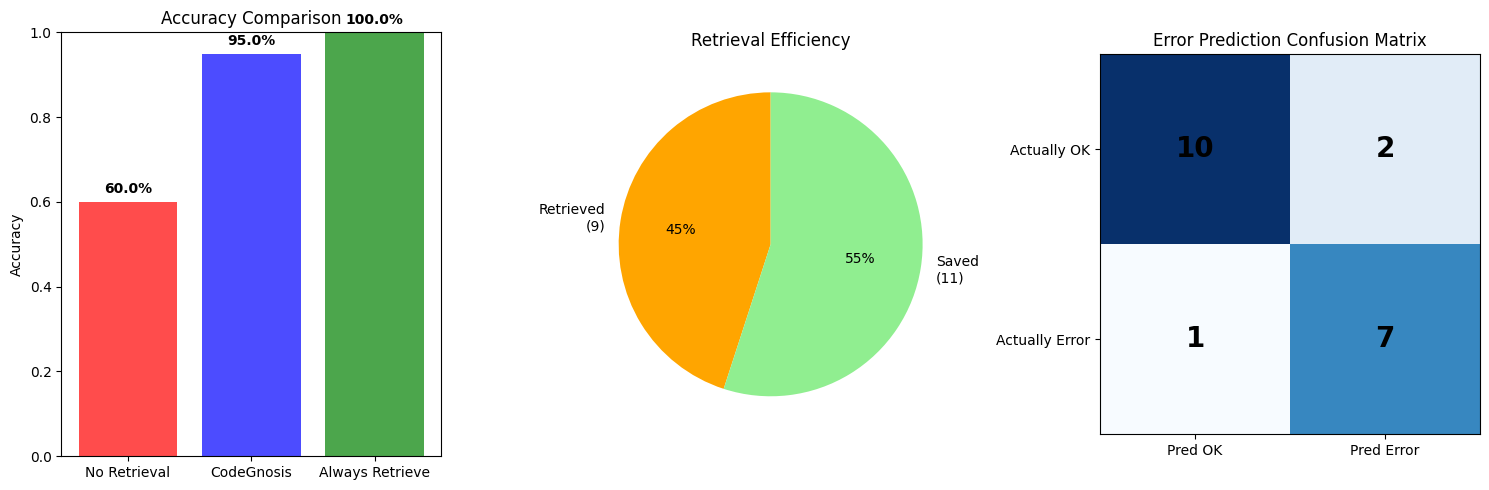

In [19]:
if clf is not None:
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Accuracy comparison
    ax1 = axes[0]
    conditions = ['No Retrieval', 'CodeGnosis', 'Always Retrieve']
    accuracies = [acc_initial, acc_final, acc_always]
    colors = ['red', 'blue', 'green']
    bars = ax1.bar(conditions, accuracies, color=colors, alpha=0.7)
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy Comparison')
    ax1.set_ylim(0, 1)
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1%}', ha='center', fontweight='bold')

    # 2. Retrieval efficiency
    ax2 = axes[1]
    sizes = [retrieval_count, n - retrieval_count]
    labels = [f'Retrieved\n({retrieval_count})', f'Saved\n({n - retrieval_count})']
    colors = ['orange', 'lightgreen']
    ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%', startangle=90)
    ax2.set_title('Retrieval Efficiency')

    # 3. Confusion matrix heatmap
    ax3 = axes[2]
    cm = np.array([[TN, FP], [FN, TP]])
    im = ax3.imshow(cm, cmap='Blues')
    ax3.set_xticks([0, 1])
    ax3.set_yticks([0, 1])
    ax3.set_xticklabels(['Pred OK', 'Pred Error'])
    ax3.set_yticklabels(['Actually OK', 'Actually Error'])
    for i in range(2):
        for j in range(2):
            ax3.text(j, i, cm[i, j], ha='center', va='center', fontsize=20, fontweight='bold')
    ax3.set_title('Error Prediction Confusion Matrix')

    plt.tight_layout()
    plt.savefig('week15_v6_results.png', dpi=150)
    plt.show()

In [20]:
# Save results
if clf is not None:
    output = {
        'experiment': 'Week15_V6_Balanced_Tasks',
        'model': MODEL_NAME,
        'num_tasks': len(TASKS),
        'task_balance': {'easy': easy_count, 'hard': hard_count},
        'accuracy': {
            'no_retrieval': acc_initial,
            'codegnosis_triggered': acc_final,
            'always_retrieval': acc_always,
        },
        'error_prediction': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': {'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN},
        },
        'efficiency': {
            'retrieval_count': retrieval_count,
            'total_tasks': n,
            'savings': n - retrieval_count,
        },
        'results': [{k: v for k, v in r.items() if k != 'features'} for r in results],
    }

    with open('week15_v6_results.json', 'w') as f:
        json.dump(output, f, indent=2, default=str)

    print("Saved to week15_v6_results.json")

Saved to week15_v6_results.json
